Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [56]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [57]:
checkpoint_dir  =  Path("../checkpoints/rtpp_20251222-231813") 
checkpoint_path1 = checkpoint_dir/ "best_model_1.pth"
checkpoint_dir2 = Path("../checkpoints/etas_20251221-224107") 
checkpoint_path2 = checkpoint_dir2/ "last_model_1.pth"

## Loading a trained model

In [58]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_and_prepare_model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model, args = load_and_prepare_model(checkpoint_path=checkpoint_path1,device=device)
# model2,_ = load_and_prepare_model(checkpoint_path=checkpoint_path2,device=device)

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'rtpp', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'bg_model': 'mamba', 'bg_model_cfg': {'d_feature': 1, 'd_state': 64, 'd_model': 16, 'model_type': 'mamba', 'scale_init': 200.0}, 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'none', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'rnn_type': 'GRU', 'scale_range': 'positive', 'd_model': 32, 'rnn_dropout': 0.3, 'num_components': 32, 'dim': 1, 'epochs': 500, 'save_dir': 'checkpoints/rtpp_20251222-231813', 'cuda_id': '0', 'dataset': 'PNR_1z', 'seed': 0, 'minibatch_training': False, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'cuda': True, 'tau_mean': 0.10764365643262863, 'tau_min': 3.0597448130720295e-08, 

In [9]:
# model.bg_model = model2.bg_model

In [59]:
model.bg_model._scale

tensor(189.8022, device='cuda:0', grad_fn=<ExpBackward0>)

In [ ]:
# model.print_params()

AttributeError: 'RecurrentTPP' object has no attribute 'print_params'

## Loading the catalog

In [61]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR_1z/raw.


In [62]:
catalog_ds.full_sequence

Sequence(
  inter_times: [12554],
  arrival_times: [12553],
  t_start: 0.0,
  t_end: 1541.0,
  t_nll_start: 0.0,
  mag: [12553],
  loc: [12553, 2],
  depth: [12553],
  time_series: [92435, 1],
  time_series_times: [92435]
)

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

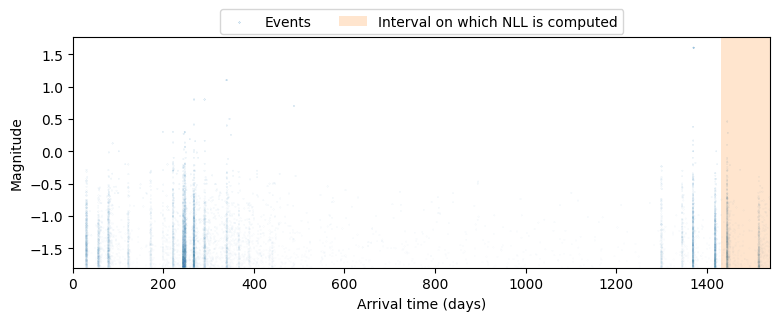

In [63]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

In [64]:
test_batch = src.data.Batch.from_list([test_seq])
test_batch.to(device)
train_batch = src.data.Batch.from_list([train_seq])
train_batch.to(device)

Batch(
  inter_times: [1, 8327],
  arrival_times: [1, 8327],
  t_start: [1],
  t_end: [1],
  t_nll_start: [1],
  nll_event_mask: [1, 8327],
  input_mask: [1, 8327],
  start_idx: [1],
  end_idx: [1],
  non_pad_mask: [1, 8327],
  type_seq: [1, 8327],
  mag: [1, 8327],
  loc: [1, 8327, 2],
  depth: [1, 8327],
  time_series: [1, 54185, 1],
  time_series_times: [1, 54185]
)

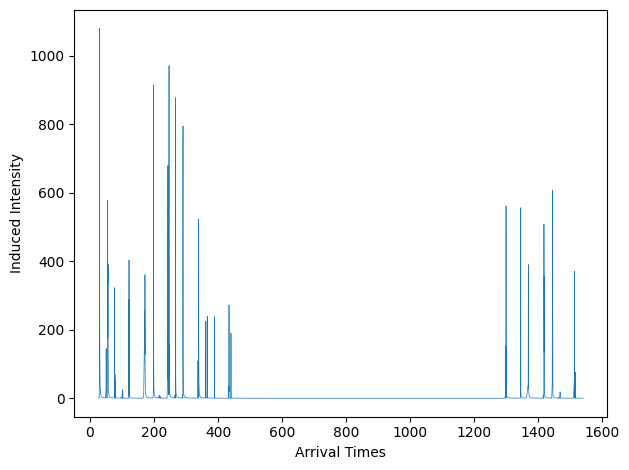

In [65]:
f_intensity= model.bg_model.intensity(test_batch)
plt.plot(
    test_batch.arrival_times.reshape(-1).detach().cpu().numpy(),
    f_intensity.reshape(-1).detach().cpu().numpy(),
    linewidth=0.5,
    color='tab:blue'
)
plt.xlabel('Arrival Times')
plt.ylabel('Induced Intensity')
plt.tight_layout()
plt.savefig(checkpoint_dir/'induced_intensity.png')

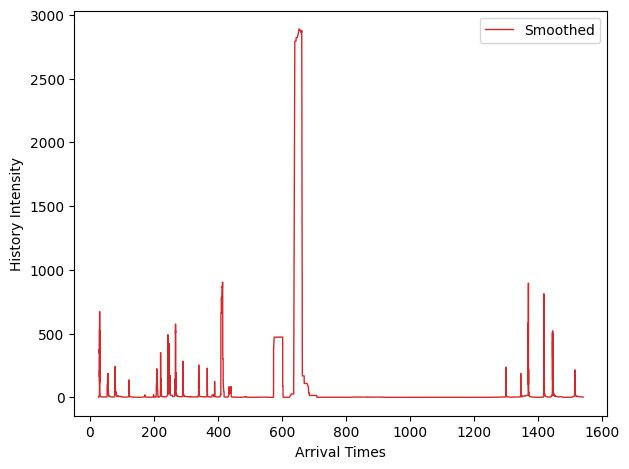

In [67]:
### rtpp
context = model.get_context(test_batch)
inter_time_dist = model.get_inter_time_dist(context)
log_h_intensity = inter_time_dist.log_hazard(test_batch.inter_times.clamp_min(1e-10))
h_intensity = torch.exp(log_h_intensity)
h_intensity_copied = torch.where(h_intensity > 100000, torch.tensor(0.0, device=h_intensity.device), h_intensity)

window = 20  # smoothing window size
arrival_times_np = test_batch.arrival_times.detach().cpu().numpy().ravel()
raw_np = h_intensity_copied.detach().cpu().numpy().ravel()
smoothed = np.convolve(raw_np, np.ones(window) / window, mode='same')

plt.xlabel('Arrival Times')
plt.ylabel('History Intensity')
# plt.plot(arrival_times_np, raw_np, linewidth=0.5, color='tab:blue', label='Raw')
plt.plot(arrival_times_np, smoothed, linewidth=1.0, color='tab:red', label='Smoothed')
plt.legend()
plt.tight_layout()
### etas
# h_intensity= model.h_intensity(test_batch)
# plt.plot(
#     test_batch.arrival_times.reshape(-1)[:-1].detach().cpu().numpy(),
#     h_intensity.reshape(-1).detach().cpu().numpy(),
#     linewidth=0.5,
#     color='tab:blue'
# )
# plt.xlabel('Arrival Times')
# plt.ylabel('Hawkes Intensity')
# plt.tight_layout()
# plt.savefig(checkpoint_dir/'hawkes_intensity.png')

In [68]:
(h_intensity > 1000).sum().item()

203

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [69]:
t_forecast = 1430 # 1460
duration = 90 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast,reset_t_nll_to_end=True) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration,reset_t_nll_to_end=True)

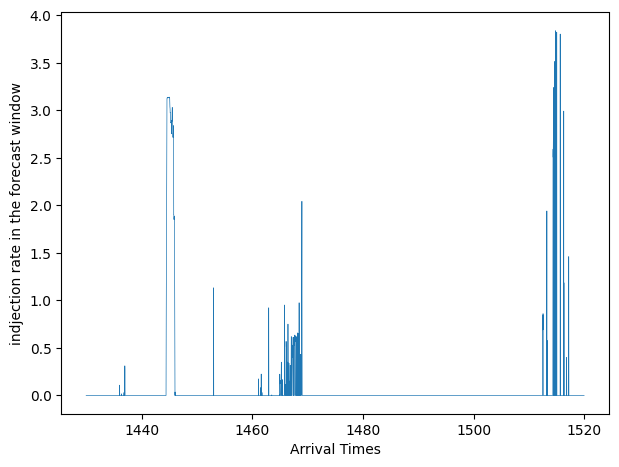

In [70]:
mask  = (test_seq.time_series_times >= t_forecast) & (test_seq.time_series_times < t_forecast + duration)
future_time_series = test_seq.time_series[mask]
future_time_series_times = test_seq.time_series_times[mask]
plt.xlabel('Arrival Times')
plt.ylabel('indjection rate in the forecast window')
plt.tight_layout()
plt.plot(future_time_series_times,
          future_time_series.reshape(-1).detach().cpu().numpy(),
           linewidth=0.5,
         color='tab:blue')

## Generate the forecast

In [71]:
past_batch = src.data.Batch.from_list([past_seq.float()])

In [72]:
past_seq

Sequence(
  inter_times: [10732],
  arrival_times: [10731],
  t_start: 0.0,
  t_end: 1430.0,
  t_nll_start: 1429.9,
  mag: [10731],
  loc: [10731, 2],
  depth: [10731],
  time_series: [85745, 1],
  time_series_times: [85745]
)

In [73]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

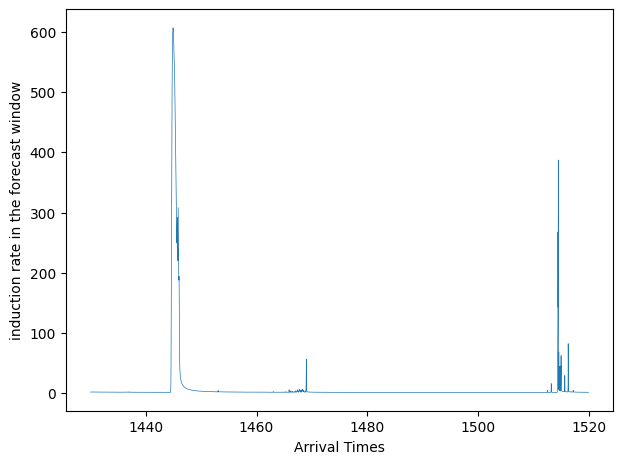

In [74]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))
model.bg_model.ts_batch_cache
times_all = test_seq.time_series_times
mask = (times_all >= t_forecast) & (times_all < t_forecast + duration)
f_intensity = model.bg_model.intensity(ts_batch=model.bg_model.ts_batch_cache,t_query=times_all[mask].unsqueeze(0))
plt.xlabel('Arrival Times')
plt.ylabel('induction rate in the forecast window')
plt.tight_layout()
plt.plot(times_all[mask], f_intensity.reshape(-1).detach().cpu().numpy(), linewidth=0.5, color='tab:blue')

1683

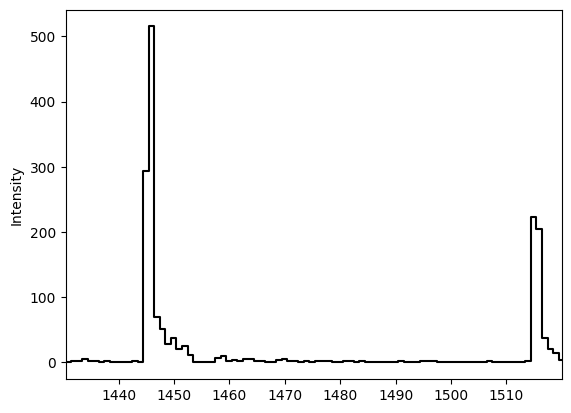

In [75]:
from src.utils.visualization import  plot_intensity
plot_intensity(observed_seq,dt=1)
len(observed_seq)

In [76]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))

In [ ]:
# model.bg_model.set_scale(200)   
# model.bg_model._scale   
# model.set_params(mu=0.14)

tensor(200.0000, device='cuda:0', grad_fn=<ExpBackward0>)

In [78]:
model.nll_loss(train_batch), model.nll_loss(test_batch)

f_intensity max:     1079.9290771484375, h_intensity max: 54159.3515625
nll_bg mean: -2489.877685546875, nll_total mean: -22097.3984375
f_intensity max:     1079.9290771484375, h_intensity max: 54159.3515625
nll_bg mean: -474.9644775390625, nll_total mean: -6699.3173828125


(tensor([-29.7008], device='cuda:0', grad_fn=<DivBackward0>),
 tensor([-61.4616], device='cuda:0', grad_fn=<DivBackward0>))

In [79]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode
all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 2 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 3 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 4 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


In [80]:
zero_indices = []
for idx, fc in enumerate(all_forecasts):
    t = torch.as_tensor(fc.inter_times).cpu()
    if (t == 0).any():
        zero_indices.append(idx)

if zero_indices:
    print("Found zeros in inter_times at indices:", zero_indices)
else:
    print("No zeros found in inter_times of any forecast.")
print("Number of forecasts with zero inter_times:", len(zero_indices))

Found zeros in inter_times at indices: [1, 7, 15, 17, 23, 24, 37, 38, 47, 48, 49, 53, 61, 64, 73, 85, 89, 100, 114, 119, 120, 121, 122, 124, 128, 129, 134, 141, 148, 155, 157, 167, 175, 179, 180, 182, 183, 188, 210, 212, 220, 221, 227, 232, 233, 235, 237, 242, 246, 249, 260, 261, 262, 270, 283, 296, 308, 310, 331, 336, 338, 346, 351, 355, 359, 360, 363, 372, 373, 385, 386, 389, 392, 397, 400, 404, 408, 418, 420, 421, 438, 440, 441, 444, 447, 451, 456, 457, 461, 462, 468, 470, 474, 475, 486, 490, 499, 507, 513, 514, 516, 517, 526, 531, 542, 544, 553, 555, 562, 563, 566, 573, 574, 582, 588, 590, 600, 611, 619, 620, 630, 642, 650, 659, 665, 676, 677, 680, 689, 691, 697, 698, 706, 714, 720, 731, 734, 748, 752, 754, 759, 767, 776, 784, 793, 795, 798, 800, 803, 809, 826, 841, 843, 844, 849, 850, 864, 867, 868, 870, 892, 899, 904, 908, 921, 929, 931, 952, 956, 969, 970, 981, 983, 986, 988, 991, 994, 1004, 1010, 1013, 1019, 1024, 1026, 1027, 1036, 1037, 1040, 1060, 1065, 1067, 1071, 1075, 1079

`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [81]:
model.bg_model.forecast_count(t_forecast, t_forecast + duration)
# model.bg_model.forecast_count(t_forecast+5, t_forecast + 10)

tensor(750.7026, device='cuda:0')

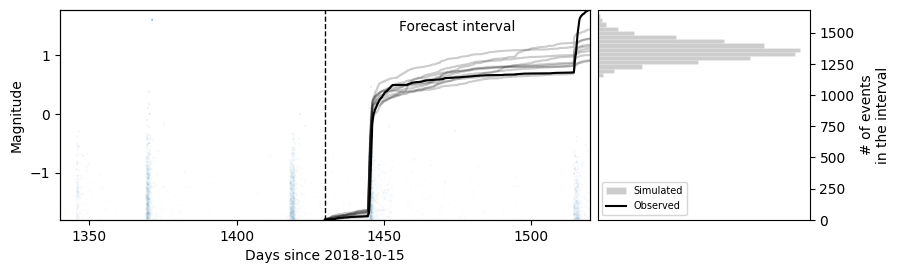

In [82]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str,reset_t_nll_to_end=True)

In [ ]:
import  src.utils.catalog_tests as catalog_tests

In [ ]:
test_seq

Sequence(
  inter_times: [12554],
  arrival_times: [12553],
  t_start: 0.0,
  t_end: 1541.0,
  t_nll_start: 1432.0,
  mag: [12553],
  loc: [12553, 2],
  depth: [12553],
  time_series: [92405, 1],
  time_series_times: [92405]
)

N-test

In [ ]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

In [ ]:
mag_max = [all_forecasts[i].mag.max().item() for i in range(len(all_forecasts))]
mag_min = [all_forecasts[i].mag.min().item() for i in range(len(all_forecasts))]
max(mag_max), min(mag_min)

(4.534012021674942, -1.799999899103154)

In [ ]:
observed_seq.mag.max().item(), observed_seq.mag.min().item()

(0.46000000834465027, -1.7990000247955322)

M-test

In [ ]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 5,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [ ]:
import matplotlib
importlib.reload(src.utils.catalog_tests)

<module 'src.utils.catalog_tests' from '/root/autodl-tmp/chuandian_eq/src/utils/catalog_tests.py'>

In [ ]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts[:10],
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,  
    debug=False
)

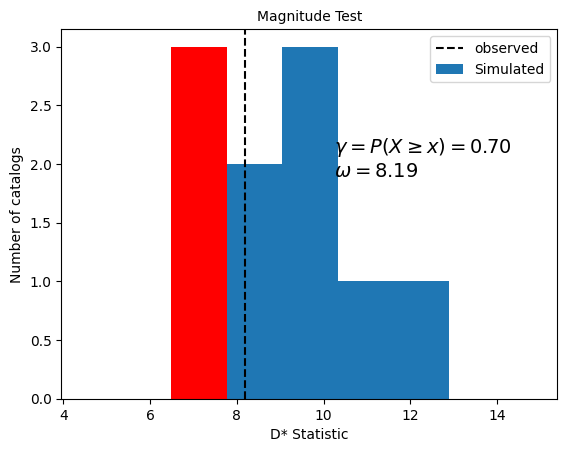

In [ ]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [ ]:
start = int(test_seq.arrival_times[0].item())
end   = int(test_seq.arrival_times[-1].item())

duration = 12
slide_step = 12
quantiles = (2.5, 97.5)
samples_per_batch = 1000

t_forecast_list = range(start + duration, end - duration, slide_step)

counts_list = []
q_list = []
mean_list = []
forecasts_counts_list = []

model.eval()

for t_forecast in t_forecast_list:
        t_end = min(t_forecast + duration, end)

        past_seq = test_seq.get_subsequence(
            0, t_forecast, reset_t_nll_to_end=True
        ).to(device)
        observed_seq = test_seq.get_subsequence(
            t_forecast, t_end, reset_t_nll_to_end=True
        ).to(device)

        all_forecasts = model.sample(
            batch_size=samples_per_batch,
            duration=(t_end - t_forecast),
            past_seq=past_seq,
            return_sequences=True
        )

        forecasts_counts = np.fromiter((len(fc) for fc in all_forecasts), dtype=np.int32)

        q = np.percentile(forecasts_counts, quantiles)
        mean = forecasts_counts.mean()

        q_list.append(q)
        mean_list.append(mean)
        true_counts = len(observed_seq)
        counts_list.append(true_counts)
        forecasts_counts_list.append(forecasts_counts)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

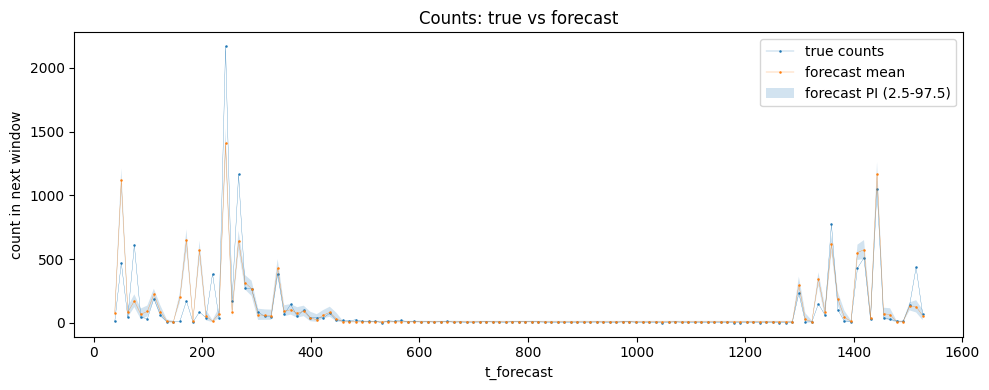

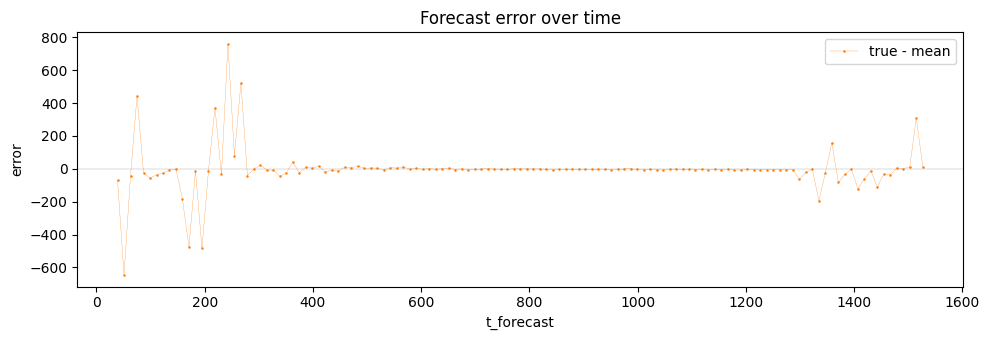

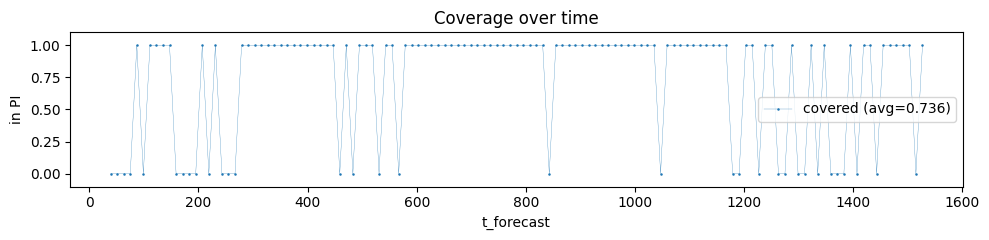

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array(list(t_forecast_list))
counts = np.array(counts_list)                  # shape: (T,)
means  = np.array(mean_list)                    # shape: (T,)
qs     = np.array(q_list)                       # shape: (T, 2)  -> [low, high]
q_low, q_high = qs[:, 0], qs[:, 1]

plt.figure(figsize=(10,4))
plt.plot(x, counts, label="true counts",linewidth=0.2,marker='o',markersize=0.8)
plt.plot(x, means,  label="forecast mean",linewidth=0.2,marker='o',markersize=0.8)
plt.fill_between(x, q_low, q_high, alpha=0.2, label="forecast PI (2.5-97.5)")
plt.xlabel("t_forecast")
plt.ylabel("count in next window")
plt.title("Counts: true vs forecast")
plt.legend()
plt.tight_layout()
plt.savefig(checkpoint_dir/'forecast_counts_over_time.png')
plt.show()

err = counts - means
plt.figure(figsize=(10,3.5))
plt.plot(x, err, label="true - mean",linewidth=0.2,marker='o',markersize=0.8,color='tab:orange')
plt.axhline(0,linewidth=0.2,color='gray')
plt.xlabel("t_forecast")
plt.ylabel("error")
plt.title("Forecast error over time")
plt.legend()
plt.tight_layout()
plt.savefig(checkpoint_dir/'forecast_error_over_time.png')
plt.show()


covered = (counts >= q_low) & (counts <= q_high)
coverage = covered.mean()
plt.figure(figsize=(10,2.5))
plt.plot(x, covered.astype(int), label=f"covered (avg={coverage:.3f})",linewidth=0.2,marker='o',markersize=0.8)
plt.ylim(-0.1, 1.1)
plt.xlabel("t_forecast")
plt.ylabel("in PI")
plt.title("Coverage over time")
plt.legend()
plt.tight_layout()
plt.show()
